In [16]:
# datasetgen.ipynb
# 02/Apr/2026

# Genera un dataset con 1.000.000 muestras (datos) linealmente separables  
# Cada muestra es un punto con coordenadas (x,y) entre -100 y 100
# Los puntos se dividen en dos conjuntos, a cada lado de la recta y=2x-25
# Cada punto está etiquetado, indicando a qué conjunto pertenece                   
# Guarda los datos en disco, con algún formato del libro Python Crash Course  
                 
# Tipo de datos (dtype) float32, para mayor claridad y simplicidad del código
# Training set (75% of data). Se usa para entrenar el modelo
# Validation set (15%). Para ajustar los hyperparameters (number of layers), monitorizar el overfitting y parar el aprendizaje cuando la pérdida deja de mejorar
# Test set (15%). Touched only once, at the very end, to give an unbiased estimate of final model performance. 

import os
import numpy as np
import matplotlib.pyplot as plt

# Número de muestras en cada parte del dataset, para 1.000 muestras en total
NUM_TRAIN_SAMPLES = 750
NUM_VAL_SAMPLES = 150
NUM_TEST_SAMPLES = 150

# Número de muestras en cada parte del dataset, para 1.000.000 muestras en total
NUM_TRAIN_SAMPLES = 900_000
NUM_VAL_SAMPLES = 50_000
NUM_TEST_SAMPLES = 50_000



# 1000: 750 / 150 / 150
# 1.000.000: 750.000 / 150.000 / 150.000


# Constants for range
MAX_RAN = 100
MIN_RAN = -100

# Genero las muestras y etiquetas de entrenamiento usando NumPY Vectorized Operations = calcular todos los valores a la vez

# Genero una matriz de NUM_TRAIN_SAMPLES filas y 2 columnas
# 1. Generate values between 0 and 1
# 2. Multiply by 200 (makes range 0 to 200)
# 3. Subtract 100 (makes range -100 to 100)
train_points = np.random.rand(NUM_TRAIN_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN

# 2. Extract x and y columns
x = train_points[:, 0]   # Todos los valores de x
y = train_points[:, 1]   # Todos los valores de y

# 3. Define the line: y_line = 2*x - 5
# Logic: If (y < 2*x - 5) → 1 (Right), else 0 (Left)
train_labels = (y < (2 * x - 25)).astype(np.float32)

# Genero las muestras y etiquetas de validación
validation_points = np.random.rand(NUM_VAL_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN
x = validation_points[:, 0]   # Todos los valores de x
y = validation_points[:, 1]   # Todos los valores de y
validation_labels = (y < (2 * x - 25)).astype(np.float32)

# Genero las muestras y etiquetas de test
test_points = np.random.rand(NUM_TEST_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN
x = test_points[:, 0]   # Todos los valores de x
y = test_points[:, 1]   # Todos los valores de y
test_labels = (y < (2 * x - 25)).astype(np.float32)


In [17]:
# Show the first 5 entries to verify
print("\nFirst 5 (x, y) points and their labels (0=Left, 1=Right):")
for i in range(5):
    print(f"Point: {train_points[i].tolist()} -> Label: {train_labels[i].item()}")


First 5 (x, y) points and their labels (0=Left, 1=Right):
Point: [20.252700805664062, -93.5787124633789] -> Label: 1.0
Point: [-54.48769760131836, 24.190834045410156] -> Label: 0.0
Point: [29.23760986328125, 13.693962097167969] -> Label: 1.0
Point: [-90.77210998535156, 12.495079040527344] -> Label: 0.0
Point: [-52.13576126098633, -85.4682388305664] -> Label: 0.0


In [27]:
# Muestro el tamaño y las propiedades de los arrays de entrenamiento para comprobar

print(f"train_points dimensions: {train_points.ndim}")
print(f"train_points dtype: {train_points.dtype}")
print(f"train_points shape: {train_points.shape}")
print(f"train_points type: {type(train_points)}")
print()

print(f"train_labels dimensions: {train_labels.ndim}")
print(f"train_labels dtype: {train_labels.dtype}")
print(f"train_labels shape: {train_labels.shape}")
print(f"train_labels type: {type(train_labels)}")
print()

train_points dimensions: 2
train_points dtype: float32
train_points shape: (900000, 2)
train_points type: <class 'numpy.ndarray'>

train_labels dimensions: 1
train_labels dtype: float32
train_labels shape: (900000,)
train_labels type: <class 'numpy.ndarray'>



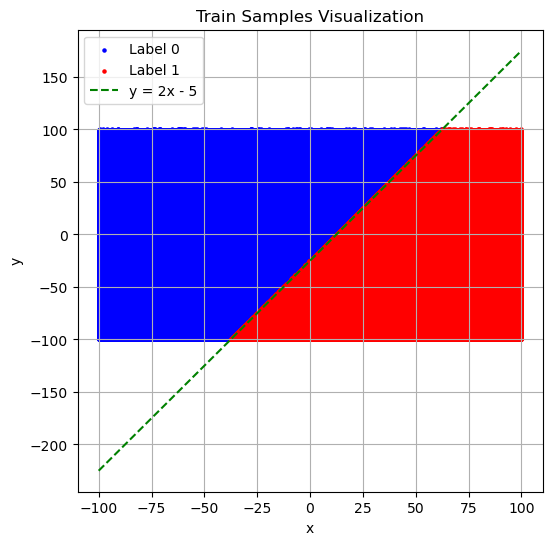

In [28]:
# Visualizo el conjunto de Entrenamiento

x = train_points[:, 0]
y = train_points[:, 1]

# Convert labels to boolean masks
mask_0 = train_labels == 0
mask_1 = train_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train Samples Visualization")
plt.legend()
plt.grid(True)

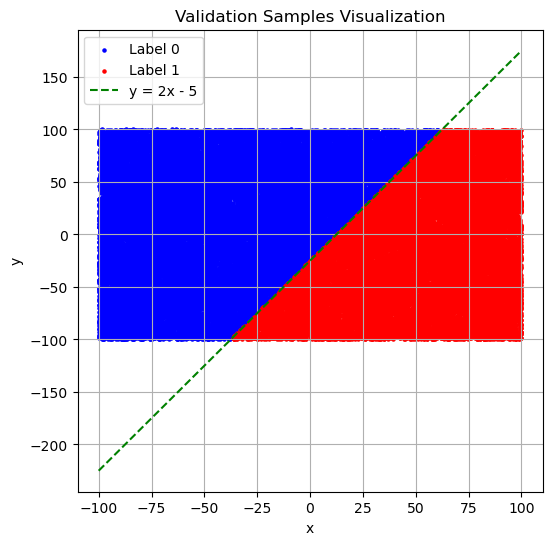

In [20]:
# Visualizo el conjunto de Validación

x = validation_points[:, 0]
y = validation_points[:, 1]

# Convert labels to boolean masks
mask_0 = validation_labels == 0
mask_1 = validation_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Validation Samples Visualization")
plt.legend()
plt.grid(True)

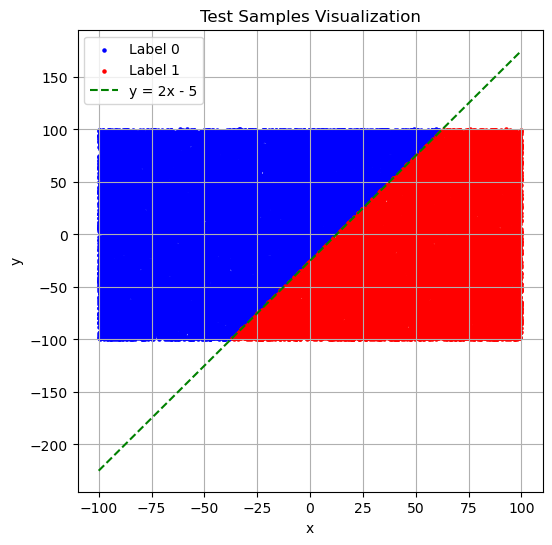

In [21]:
# Visualizo el conjunto de Prueba

x = test_points[:, 0]
y = test_points[:, 1]

# Convert labels to boolean masks
mask_0 = test_labels == 0
mask_1 = test_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Test Samples Visualization")
plt.legend()
plt.grid(True)

In [23]:
# Guarda el fichero en disco
np.savez_compressed(
    "dataset.npz",
    train_points=train_points,
    train_labels=train_labels,
    validation_points=validation_points,
    validation_labels=validation_labels,
    test_points=test_points,
    test_labels=test_labels,
)

In [26]:
# Carga los datos desde disco
dataset = np.load("dataset.npz")
train_points  = dataset["train_points"]
train_labels  = dataset["train_labels"]
validation_points    = dataset["validation_points"]
validation_labels    = dataset["validation_labels"]
test_points   = dataset["test_points"]
test_labels   = dataset["test_labels"]